In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
class network:
    """
    Network representation
    """
    def __init__(self, nodes, arcs, coordinates = None):
        """Constructor
        :param nodes: list with the names of the m nodes
        :type nodes: list(str)
        :param arcs: a list of tuples (n1, n2, c) where
        - n1 is the name of the upstream node
        - n2 is the name of the downstream node
        - c is the cost of the arc.
        :type arcs: list(str, str, float)
        :param coordinates: coordinates of the nodes for graphical representation
        :type nodes: list(float, float)
        """
        self.nodes = nodes
        self.arcs = arcs
        self.arcCosts = {}
        self.coordinates = coordinates
        self.m = len(nodes)
        self.n = len(arcs)
        self.successors = [list() for i in range(self.m)]
        self.negativeCosts = False
        self.minCost = None
        for n1, n2, c in arcs:
            self.arcCosts[(n1, n2)] = c
            i1 = self.nodeIndex(n1)
            i2 = self.nodeIndex(n2)
            self.successors[i1].append((i2, c))
            if self.minCost is None:
                self.minCost = c
            elif c < self.minCost:
                self.minCost = c
            if c < 0:
                self.negativeCosts = True

    def nodeIndex(self, node):
        """
        The nodes are numbered from 0 to m - 1. The index is this
        internal number of the node.
        """
        return self.nodes.index(node)

    def draw(self):
        """
        A simple drawing of the graph based on the networkx package.
        """
        g = nx.DiGraph()
        for n, c in zip(self.nodes, self.coordinates):
            g.add_node(n, pos=c)
        edge_labels = {}
        for n1, n2, c in self.arcs:
            g.add_edge(n1, n2, cost = c)
            edge_labels[(n1, n2)] = f'{c}'
        pos = nx.get_node_attributes(g, 'pos')
        nx.draw(g, pos, with_labels = True, font_weight = 'bold')
        nx.draw_networkx_edge_labels(g, pos, edge_labels = edge_labels)
        g.clear()

In [16]:
def shortestPath(network, startingNode):
    """
    :param network: the network.
    :type network: class network
    :param startingNode: name of the starting node.
    :type startingNode: str
    """
    def generateOutput():
        """
        Function preparing the output.
        """
        return {network.nodes[i]: (labels[i], network.nodes[pred[i]]) if pred[i] is not None else (labels[i], None) for i in range(m)}
    
    m = network.m
    n = network.n
    # We check if there are negative costs and, if so, we calculate the lower bound.
    if network.negativeCosts:
        lowerbound = (m - 1) * network.minCost
    # Initialization of the labels.
    labels = [np.inf for i in range(m)]
    i0 = network.nodeIndex(startingNode)
    labels[i0] = 0
    # Initialization of the predecessors
    pred = [None for i in range(m)]
    # Initialization of the set.
    S = set([i0])
    while S:
        # Choose a random node in the set and remove it
        i = S.pop()
        print(f'pop {i}')
        # Process all the successors.
        for j, c in network.successors[i]:
            if labels[j] > labels[i] + c:
                labels[j] = labels[i] + c
                if labels[j] < 0 and labels[j] < lowerbound:
                    print(f'The label of node {network.nodes[j]} is {labels[j]}, that is below the lower bound {lowerbound}. It is an unbounded problem.')
                    return generateOutput()
                S.add(j)
                print(f'add {j}')
                print(S)
                pred[j] = i
    return generateOutput()

In [8]:
def printLabels(labels):
    for k, v in labels.items():
        print(f'Label of node {k}: {v[0]}. Predecessor in the shortest path:,→{v[1]}')

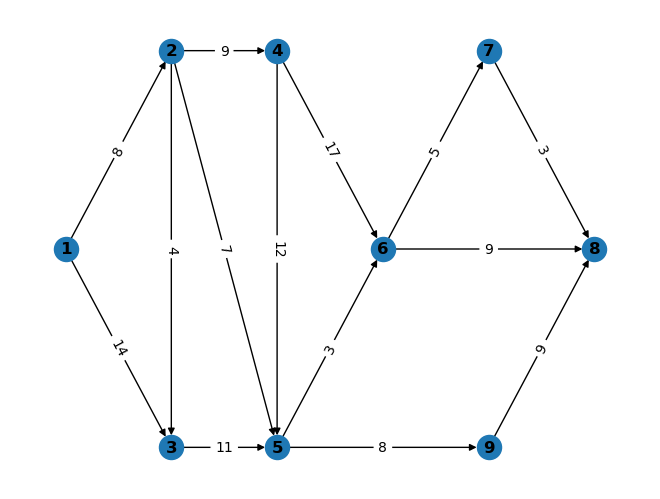

Label of node 1: 0. Predecessor in the shortest path:,→None
Label of node 2: 8. Predecessor in the shortest path:,→1
Label of node 3: 12. Predecessor in the shortest path:,→2
Label of node 4: 17. Predecessor in the shortest path:,→2
Label of node 5: 15. Predecessor in the shortest path:,→2
Label of node 6: 18. Predecessor in the shortest path:,→5
Label of node 7: 23. Predecessor in the shortest path:,→6
Label of node 8: 26. Predecessor in the shortest path:,→7
Label of node 9: 23. Predecessor in the shortest path:,→5
Arc 1->2 Cost: 8
Arc 2->3 Cost: 4
Arc 2->4 Cost: 9
Arc 2->5 Cost: 7
Arc 5->6 Cost: 3
Arc 6->7 Cost: 5
Arc 7->8 Cost: 3
Arc 5->9 Cost: 8


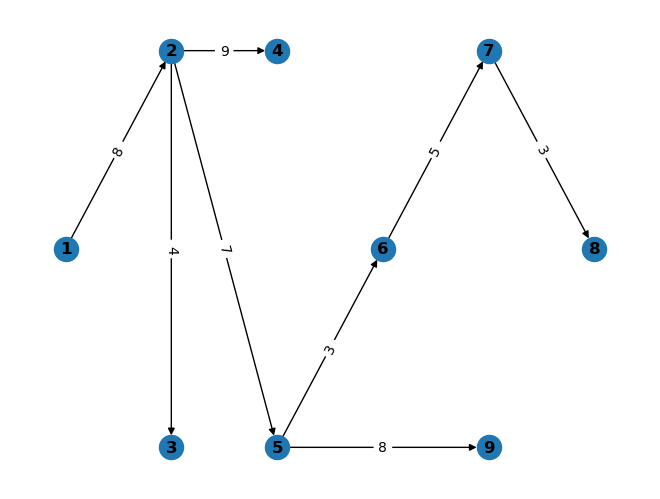

In [13]:
nodes = [f'{i}' for i in range(1, 10)]
coordinates = [(0, 0),
(2, 1.5),
(2, -1.5),
(4, 1.5),
(4, -1.5),
(6, 0),
(8, 1.5),
(10, 0),
(8, -1.5)]
arcs = [('1', '2', 8),
('1', '3', 14),
('2','3', 4),
('2','4', 9),
('2','5', 7),
('3', '5', 11),
('4', '5', 12),
('4', '6', 17),
('5', '6', 3),
('5', '9', 8),
('6', '7', 5),
('6', '8', 9),
('7', '8', 3),
('9', '8', 9)]
theNetwork = network(nodes, arcs, coordinates)
theNetwork.draw()
plt.show()
labels = shortestPath(theNetwork, '1')
printLabels(labels)
shortestPathArcs = [(v[1], k, theNetwork.arcCosts[(v[1], k)]) for k, v in labels.items() if v[1] is not None]
for a in shortestPathArcs:
    print(f'Arc {a[0]}->{a[1]} Cost: {a[2]}')
theShortestPathTree = network(nodes, shortestPathArcs, coordinates)
theShortestPathTree.draw()

pop 0
add 1
{1}
add 2
{1, 2}
pop 1
add 3
{2, 3}
add 4
{2, 3, 4}
pop 2
add 1
{1, 3, 4}
pop 3
add 5
{1, 4, 5}
pop 4
add 5
{1, 5}
add 2
{1, 2, 5}
pop 5
pop 1
add 3
{2, 3}
add 4
{2, 3, 4}
pop 2
add 1
{1, 3, 4}
pop 3
pop 4
add 5
{1, 5}
add 2
{1, 2, 5}
pop 1
add 3
{3, 2, 5}
add 4
{3, 2, 5, 4}
pop 2
add 1
{3, 1, 5, 4}
pop 5
pop 4
add 5
{3, 1, 5}
add 2
{3, 1, 2, 5}
pop 3
pop 1
add 3
{3, 2, 5}
add 4
{4, 3, 2, 5}
pop 2
add 1
{4, 3, 1, 5}
pop 5
pop 4
add 5
{3, 1, 5}
add 2
{2, 3, 1, 5}
pop 3
pop 1
add 3
{2, 3, 5}
add 4
{2, 4, 3, 5}
pop 5
pop 2
add 1
{4, 3, 1}
pop 4
add 5
{5, 3, 1}
add 2
{2, 5, 3, 1}
pop 3
pop 1
add 3
{2, 5, 3}
add 4
{2, 5, 4, 3}
pop 2
add 1
{1, 5, 4, 3}
pop 5
pop 4
add 5
{1, 5, 3}
add 2
{1, 2, 5, 3}
pop 3
pop 1
add 3
{2, 5, 3}
add 4
{4, 2, 5, 3}
pop 2
add 1
{4, 1, 5, 3}
pop 5
pop 3
pop 4
add 5
{1, 5}
add 2
{1, 2, 5}
pop 1
add 3
{3, 2, 5}
add 4
{4, 3, 2, 5}
pop 2
add 1
{4, 3, 1, 5}
pop 5
pop 4
add 5
{3, 1, 5}
add 2
{2, 3, 1, 5}
pop 3
pop 1
add 3
{2, 3, 5}
add 4
{2, 4, 3, 5}
pop 5
p

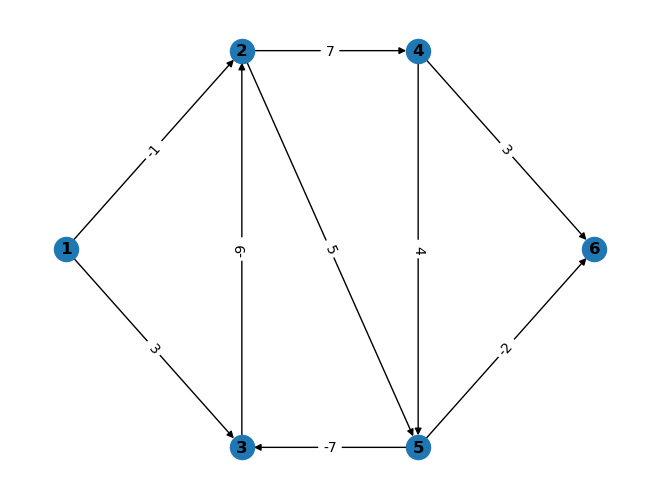

In [17]:
nodes = [f'{i}' for i in range(1, 7)]
coordinates = [(0, 0),
(2, 1.5),
(2, -1.5),
(4, 1.5),
(4, -1.5),
(6, 0)]
arcs = [
('1', '2', -1),
('1', '3', 3),
('2', '4', 7),
('2', '5', 5),
('3', '2', -9),
('4', '5', 4),
('4', '6', 3),
('5', '6', -2),
('5', '3', -7)
]
theNetwork = network(nodes, arcs, coordinates)
theNetwork.draw()
labels = shortestPath(theNetwork, '1')
printLabels(labels)

pop 0
add 1
{1}
add 2
{1, 2}
pop 1
pop 2
add 1
{1}
pop 1
Label of node 1: 0. Predecessor in the shortest path:,→None
Label of node 2: 2. Predecessor in the shortest path:,→3
Label of node 3: 5. Predecessor in the shortest path:,→1


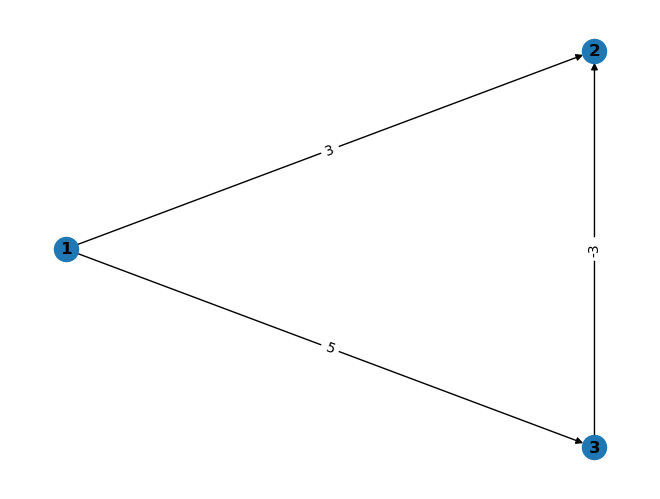

In [21]:
nodes = [f'{i}' for i in range(1, 4)]
coordinates = [(0, 0),
(2, 1.5),
(2, -1.5)]
arcs = [
('1', '2', 3),
('1', '3', 5),
('3', '2', -3)]
theNetwork = network(nodes, arcs, coordinates)
theNetwork.draw()
labels = shortestPath(theNetwork, '1')
printLabels(labels)